# Gradient Descent and Polynomial Regression

## Overview
In this lab, you will learn how to implement and compare three core optimization strategies used in machine learning:

- **Batch Gradient Descent (BGD)**
- **Stochastic Gradient Descent (SGD)**
- **Mini-Batch Gradient Descent (MBGD)**

You will first study the underlying mathematics and implement these methods **from scratch with NumPy**.
Then you will apply them to **polynomial regression**, analyze their behavior, and complete hands-on exercises.

## Learning Objectives
By the end of this lab, you should be able to:

1. Explain how gradient descent minimizes a cost function.
2. Derive and implement update rules for BGD, SGD, and MBGD.
3. Build polynomial features for nonlinear curve fitting.
4. Compare optimization methods in terms of speed, stability, and final performance.
5. Critically evaluate hyperparameters such as learning rate and batch size.

In [1]:
# =============================
# Imports and visual settings
# =============================
import time
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.metrics import mean_squared_error
from sklearn.preprocessing import PolynomialFeatures, StandardScaler

sns.set_theme(style="whitegrid", context="notebook")
np.random.seed(42)

print("Libraries imported successfully.")

Libraries imported successfully.


## 1) Gradient Descent: Concept and Mathematics

### Why Gradient Descent?
For many machine learning models, we define a loss (or cost) function and want to find model parameters that minimize it.
Gradient descent is an iterative optimization algorithm that updates parameters in the direction of the **negative gradient** of the loss.

### Linear Model Form
We use a hypothesis:

$$
\hat{y} = X\theta
$$

where:
- $X \in \mathbb{R}^{m \times n}$ is the design matrix,
- $\theta \in \mathbb{R}^{n \times 1}$ are model parameters,
- $\hat{y} \in \mathbb{R}^{m \times 1}$ are predictions.

### Cost Function (Mean Squared Error)

$$
J(\theta) = \frac{1}{2m} \sum_{i=1}^{m}(\hat{y}^{(i)} - y^{(i)})^2
$$

In matrix form:

$$
J(\theta) = \frac{1}{2m}(X\theta - y)^T(X\theta - y)
$$

### Gradient of MSE

$$
\nabla_\theta J(\theta) = \frac{1}{m}X^T(X\theta - y)
$$

### Update Rule

$$
\theta := \theta - \eta \nabla_\theta J(\theta)
$$

where $\eta$ is the learning rate.

---

## Three Variants

1. **Batch GD**: Uses all training examples each update.
   $$
   \theta := \theta - \eta \cdot \frac{1}{m}X^T(X\theta - y)
   $$

2. **Stochastic GD (SGD)**: Uses one sample at a time.
   $$
   \theta := \theta - \eta \cdot x_i^T(x_i\theta - y_i)
   $$

3. **Mini-Batch GD**: Uses a small batch $B$ each update.
   $$
   \theta := \theta - \eta \cdot \frac{1}{|B|}X_B^T(X_B\theta - y_B)
   $$

Trade-off intuition:
- Batch: stable but can be slow per update.
- SGD: fast, noisy updates.
- Mini-Batch: balanced and widely used in practice.

In [6]:
class GradientDescentRegressor:
    """
    Linear regressor optimized using batch, stochastic, or mini-batch GD.
    """
    def __init__(self, method="batch", lr=0.01, epochs=200, batch_size=32, random_state=42):
        self.method = method
        self.lr = lr
        self.epochs = epochs
        self.batch_size = batch_size
        self.random_state = random_state
        self.theta = None
        self.loss_history = []
        self.training_time = None

    def _compute_gradient(self, X, y):
        """Gradient of MSE cost with respect to theta."""
        m = X.shape[0]
        errors = X @ self.theta - y
        grad = (X.T @ errors) / m
        return grad

    def fit(self, X, y):
        """Train model parameters using selected GD method."""
        rng = np.random.default_rng(self.random_state)
        m, n = X.shape
        self.theta = np.zeros((n, 1))
        self.loss_history = []

        start = time.perf_counter()

        for epoch in range(self.epochs):
            if self.method == "batch":
                grad = self._compute_gradient(X, y)
                self.theta -= self.lr * grad

            elif self.method == "sgd":
                # Shuffle indices each epoch for better stochastic behavior.
                indices = rng.permutation(m)
                for i in indices:
                    Xi = X[i:i+1]
                    yi = y[i:i+1]
                    grad = Xi.T @ (Xi @ self.theta - yi)  # batch size is 1
                    self.theta -= self.lr * grad

            elif self.method == "mini-batch":
                indices = rng.permutation(m)
                for start_idx in range(0, m, self.batch_size):
                    batch_idx = indices[start_idx:start_idx + self.batch_size]
                    Xb = X[batch_idx]
                    yb = y[batch_idx]
                    grad = (Xb.T @ (Xb @ self.theta - yb)) / Xb.shape[0]
                    self.theta -= self.lr * grad

            else:
                raise ValueError("method must be 'batch', 'sgd', or 'mini-batch'")

            # Track full-dataset loss after each epoch.
            y_pred_epoch = X @ self.theta
            epoch_loss = mean_squared_error(y, y_pred_epoch)
            self.loss_history.append(epoch_loss)

        end = time.perf_counter()
        self.training_time = end - start
        return self

    def predict(self, X):
        """Predict targets for input matrix X."""
        return X @ self.theta

## 2) Simple Example: Compare BGD, SGD, and MBGD

We start with a simple linear dataset to compare convergence behavior of the three methods.

Model: $y = 4 + 3x + \epsilon$

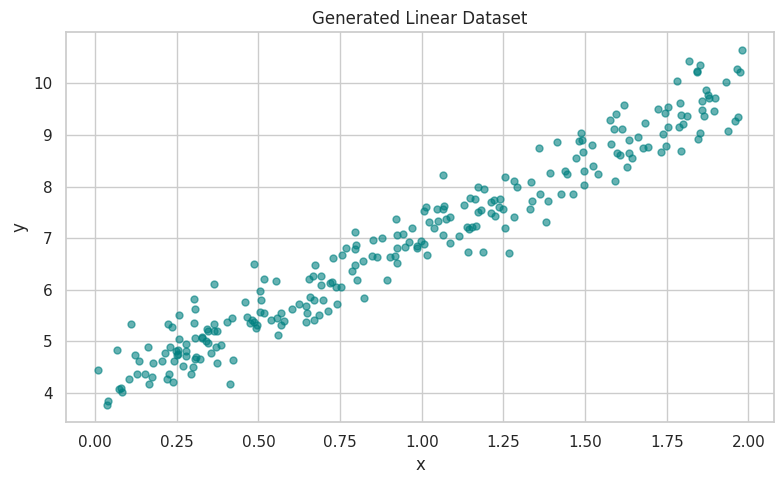

,Method,Final MSE,Training Time (s),Final Theta
0,Batch GD,0.205856,0.037862,"[3.6142597853804372, 3.3510061926326555]"
1,SGD,0.156245,0.173744,"[4.0386932094119015, 2.9754882252695607]"
2,Mini-Batch GD,0.156361,0.029508,"[4.01904630709163, 2.99510520802306]"


In [7]:
# Generate synthetic linear data
m = 250
X_raw = 2 * np.random.rand(m, 1)
noise = np.random.randn(m, 1) * 0.4
y = 4 + 3 * X_raw + noise

# Visualize dataset immediately after generation
plt.figure(figsize=(8, 5))
plt.scatter(X_raw, y, alpha=0.6, s=25, color="teal")
plt.title("Generated Linear Dataset")
plt.xlabel("x")
plt.ylabel("y")
plt.tight_layout()
plt.show()

# Add bias term for linear model
X = np.c_[np.ones((X_raw.shape[0], 1)), X_raw]

# Train all three variants
models = {
    "Batch GD": GradientDescentRegressor(method="batch", lr=0.08, epochs=50),
    "SGD": GradientDescentRegressor(method="sgd", lr=0.01, epochs=50),
    "Mini-Batch GD": GradientDescentRegressor(method="mini-batch", lr=0.03, epochs=50, batch_size=16)
}

results_simple = []

for name, model in models.items():
    model.fit(X, y)
    y_pred = model.predict(X)
    results_simple.append({
        "Method": name,
        "Final MSE": mean_squared_error(y, y_pred),
        "Training Time (s)": model.training_time,
        "Final Theta": model.theta.ravel()
    })

simple_results_df = pd.DataFrame(results_simple)
simple_results_df

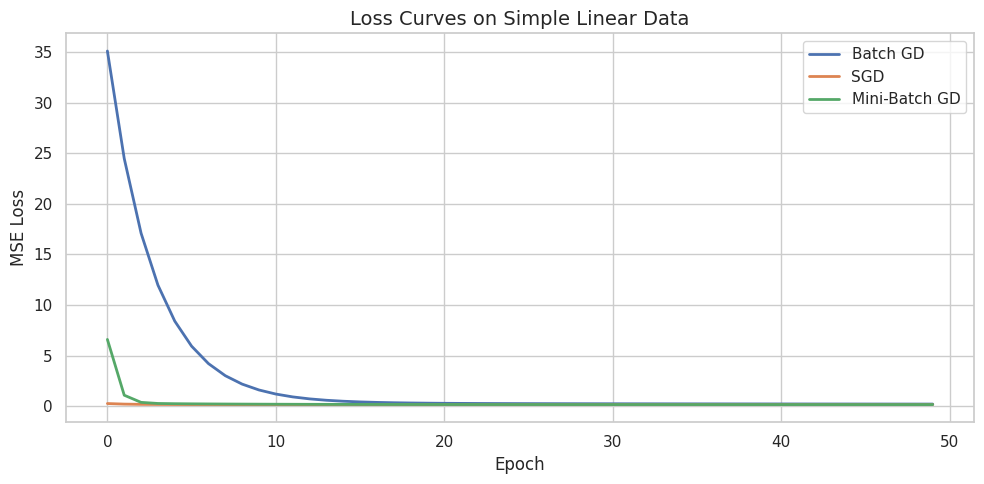

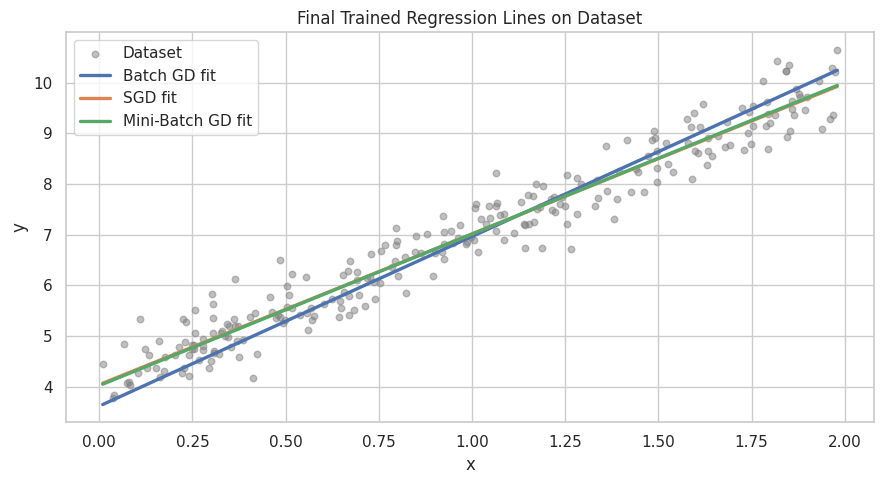

,Method,Final MSE,Training Time (s),Final Theta
1,SGD,0.156245,0.173744,"[4.0386932094119015, 2.9754882252695607]"
2,Mini-Batch GD,0.156361,0.029508,"[4.01904630709163, 2.99510520802306]"
0,Batch GD,0.205856,0.037862,"[3.6142597853804372, 3.3510061926326555]"


In [8]:
# Plot loss curves to compare convergence
plt.figure(figsize=(10, 5))
for name, model in models.items():
    plt.plot(model.loss_history, label=name, linewidth=2)

plt.title("Loss Curves on Simple Linear Data", fontsize=14)
plt.xlabel("Epoch")
plt.ylabel("MSE Loss")
plt.legend()
plt.tight_layout()
plt.show()

# Visualize final trained regression lines on top of the dataset
x_line = np.linspace(X_raw.min(), X_raw.max(), 300).reshape(-1, 1)
X_line = np.c_[np.ones((x_line.shape[0], 1)), x_line]

plt.figure(figsize=(9, 5))
plt.scatter(X_raw, y, alpha=0.5, s=22, color="gray", label="Dataset")
for name, model in models.items():
    y_line_pred = model.predict(X_line)
    plt.plot(x_line, y_line_pred, linewidth=2.4, label=f"{name} fit")

plt.title("Final Trained Regression Lines on Dataset")
plt.xlabel("x")
plt.ylabel("y")
plt.legend()
plt.tight_layout()
plt.show()

display(simple_results_df.sort_values("Final MSE"))

### Interpretation
- **Batch GD** usually gives smoother convergence because each update uses the full dataset.
- **SGD** often converges quickly at first but exhibits noisier loss curves.
- **Mini-Batch GD** balances stability and computational efficiency.

In practice, mini-batch methods are widely used because they are GPU-friendly and often converge well.

## 3) Polynomial Regression from Scratch

### Why Polynomial Features?
A linear model in the original feature space can only fit straight lines/planes.
If the relationship between $x$ and $y$ is nonlinear, we can map input $x$ to polynomial features:

$$
\phi(x) = [x, x^2, x^3, \dots, x^d]
$$

Then fit a linear model in transformed space:

$$
\hat{y} = \theta_0 + \theta_1 x + \theta_2 x^2 + \cdots + \theta_d x^d
$$

This is still linear in parameters $\theta$, so gradient descent applies directly.

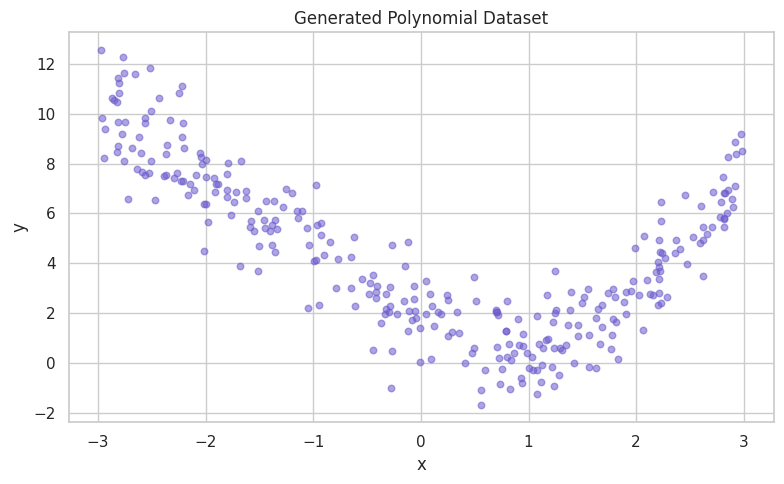

Polynomial data prepared.
Design matrix shape: (300, 4)


In [9]:
# Generate synthetic polynomial data
m_poly = 300
x_poly = np.random.uniform(-3, 3, size=(m_poly, 1))
y_poly = 1.5 - 2.0 * x_poly + 0.9 * (x_poly ** 2) + 0.2 * (x_poly ** 3) + np.random.randn(m_poly, 1) * 1.2

# Visualize dataset immediately after generation
plt.figure(figsize=(8, 5))
plt.scatter(x_poly, y_poly, alpha=0.55, s=22, color="slateblue")
plt.title("Generated Polynomial Dataset")
plt.xlabel("x")
plt.ylabel("y")
plt.tight_layout()
plt.show()

# Create polynomial features up to degree 3 using sklearn
degree = 3
poly = PolynomialFeatures(degree=degree, include_bias=False)
X_poly_raw = poly.fit_transform(x_poly)

# Standardize polynomial features for stable GD updates using sklearn
scaler = StandardScaler()
X_poly_scaled = scaler.fit_transform(X_poly_raw)

# Add explicit bias for our from-scratch GD implementation
X_poly_design = np.c_[np.ones((X_poly_scaled.shape[0], 1)), X_poly_scaled]

print("Polynomial data prepared.")
print("Design matrix shape:", X_poly_design.shape)

In [10]:
# Train polynomial regression with all three GD variants
poly_models = {
    "Batch GD": GradientDescentRegressor(method="batch", lr=0.05, epochs=250),
    "SGD": GradientDescentRegressor(method="sgd", lr=0.005, epochs=250),
    "Mini-Batch GD": GradientDescentRegressor(method="mini-batch", lr=0.02, epochs=250, batch_size=32)
}

poly_results = []
for name, model in poly_models.items():
    model.fit(X_poly_design, y_poly)
    y_pred = model.predict(X_poly_design)

    # Convergence criterion example: first epoch where loss <= 1.05 * final loss
    final_loss = model.loss_history[-1]
    threshold = 1.05 * final_loss
    epochs_to_converge = next((i + 1 for i, l in enumerate(model.loss_history) if l <= threshold), model.epochs)

    poly_results.append({
        "Method": name,
        "Final MSE": mean_squared_error(y_poly, y_pred),
        "Epochs to Converge": epochs_to_converge,
        "Training Time (s)": model.training_time
    })

poly_results_df = pd.DataFrame(poly_results)
poly_results_df

,Method,Final MSE,Epochs to Converge,Training Time (s)
0,Batch GD,1.550582,200,0.134847
1,SGD,1.394830,12,0.621783
2,Mini-Batch GD,1.391398,90,0.163475


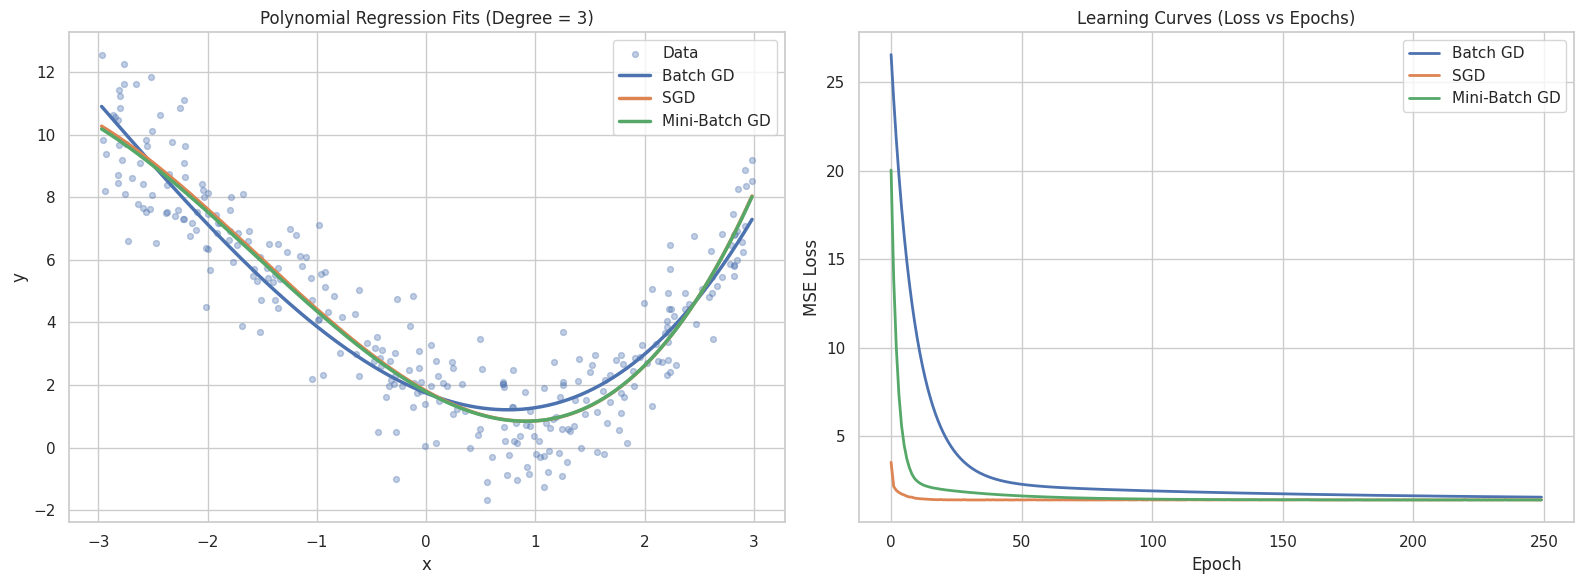

,Method,Final MSE,Epochs to Converge,Training Time (s)
2,Mini-Batch GD,1.391398,90,0.163475
1,SGD,1.394830,12,0.621783
0,Batch GD,1.550582,200,0.134847


In [11]:
# Visualize fitted curves and learning curves
x_grid = np.linspace(x_poly.min(), x_poly.max(), 400).reshape(-1, 1)
X_grid_raw = poly.transform(x_grid)
X_grid_scaled = scaler.transform(X_grid_raw)
X_grid_design = np.c_[np.ones((X_grid_scaled.shape[0], 1)), X_grid_scaled]

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Left: data + fitted curves
axes[0].scatter(x_poly, y_poly, alpha=0.35, s=18, label="Data")
for name, model in poly_models.items():
    y_grid_pred = model.predict(X_grid_design)
    axes[0].plot(x_grid, y_grid_pred, linewidth=2.5, label=name)

axes[0].set_title("Polynomial Regression Fits (Degree = 3)")
axes[0].set_xlabel("x")
axes[0].set_ylabel("y")
axes[0].legend()

# Right: learning curves
for name, model in poly_models.items():
    axes[1].plot(model.loss_history, linewidth=2, label=name)

axes[1].set_title("Learning Curves (Loss vs Epochs)")
axes[1].set_xlabel("Epoch")
axes[1].set_ylabel("MSE Loss")
axes[1].legend()

plt.tight_layout()
plt.show()

display(poly_results_df.sort_values("Final MSE"))

### Observations
- All three methods can fit polynomial regression when features are engineered properly.
- Feature scaling is critical for numerical stability, especially for high-degree polynomial terms.
- SGD may oscillate more due to noisy updates, while Batch GD is smoother.
- Mini-Batch GD often gives a strong practical compromise.

# 4) Lab Exercises (Total: 100 points)

Complete the following tasks. Write clean code, include plots, and explain your findings in markdown.

## Task 1 (25 points)
**Implement Batch Gradient Descent from scratch** for a 4nd-degree polynomial regression on a new synthetic dataset (use different coefficients and noise from tutorial).

### Requirements
- Generate your own dataset.
- Build polynomial features (degree 4).
- Train using Batch GD.
- Plot fitted curve and learning curve.

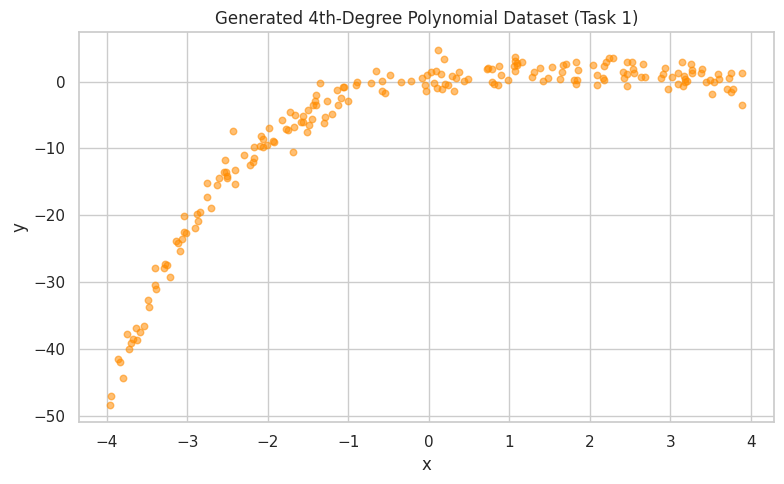

Polynomial data for Task 1 prepared.
Design matrix shape for Task 1: (200, 5)


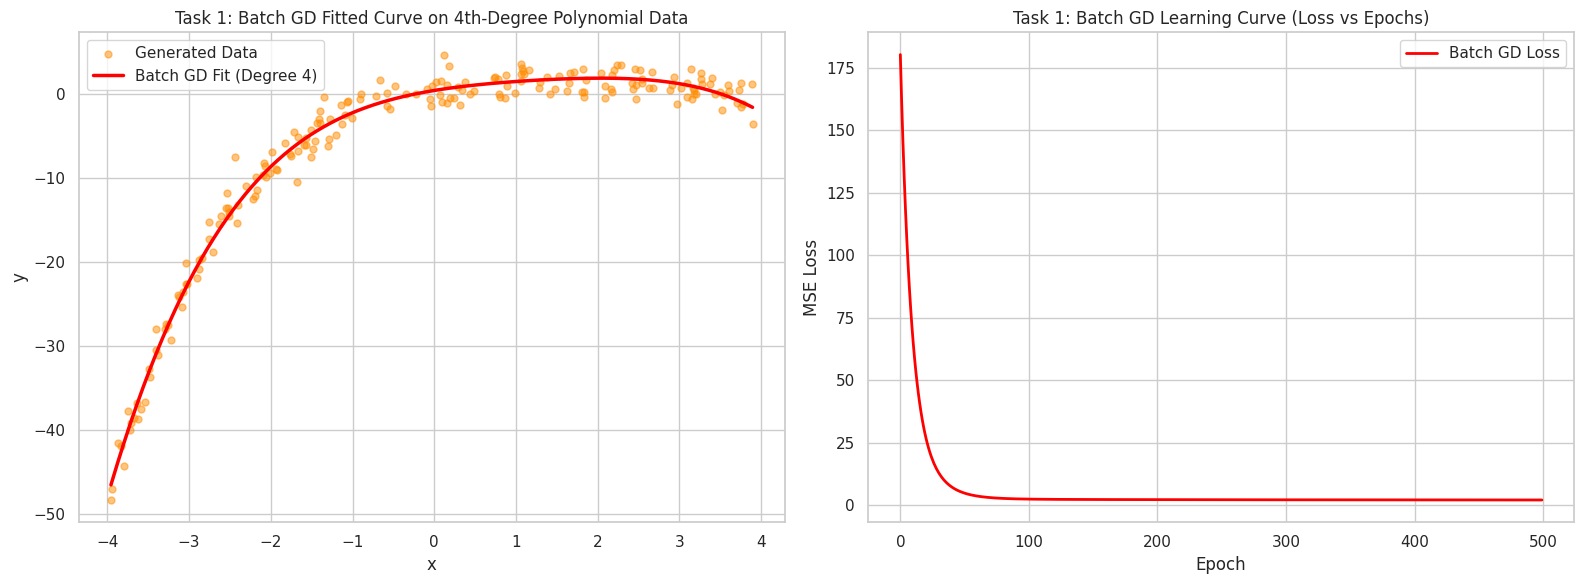

Task 1 Final MSE (Batch GD): 2.0979


In [12]:
# -----------------------------
# Task 1 starter template
# -----------------------------

# Generate a new synthetic 4th-degree polynomial dataset
m_t1 = 200
np.random.seed(42) # For reproducibility
x_t1 = np.random.uniform(-4, 4, size=(m_t1, 1))

# Example target form: y = a + b*x + c*x^2 + d*x^3 + e*x^4 + noise
y_t1 = 0.5 + 1.2 * x_t1 - 0.8 * (x_t1 ** 2) + 0.3 * (x_t1 ** 3) - 0.05 * (x_t1 ** 4) + np.random.randn(m_t1, 1) * 1.5

# Visualize dataset immediately after generation
plt.figure(figsize=(8, 5))
plt.scatter(x_t1, y_t1, alpha=0.55, s=22, color="darkorange")
plt.title("Generated 4th-Degree Polynomial Dataset (Task 1)")
plt.xlabel("x")
plt.ylabel("y")
plt.tight_layout()
plt.show()

# Build degree-4 polynomial features and standardize using sklearn.
degree_t1 = 4
poly_t1 = PolynomialFeatures(degree=degree_t1, include_bias=False)
X_t1_raw = poly_t1.fit_transform(x_t1)

scaler_t1 = StandardScaler()
X_t1_scaled = scaler_t1.fit_transform(X_t1_raw)

# Add explicit bias for our from-scratch GD implementation
X_t1_design = np.c_[np.ones((X_t1_scaled.shape[0], 1)), X_t1_scaled]

print("Polynomial data for Task 1 prepared.")
print("Design matrix shape for Task 1:", X_t1_design.shape)

# Train Batch GD.
bgd_model_t1 = GradientDescentRegressor(method="batch", lr=0.03, epochs=500)
bgd_model_t1.fit(X_t1_design, y_t1)
y_t1_pred = bgd_model_t1.predict(X_t1_design)

# Plot fitted curve and loss curve.
# Create a grid for plotting the fitted curve
x_grid_t1 = np.linspace(x_t1.min(), x_t1.max(), 400).reshape(-1, 1)
X_grid_t1_raw = poly_t1.transform(x_grid_t1)
X_grid_t1_scaled = scaler_t1.transform(X_grid_t1_raw)
X_grid_t1_design = np.c_[np.ones((X_grid_t1_scaled.shape[0], 1)), X_grid_t1_scaled]
y_grid_t1_pred = bgd_model_t1.predict(X_grid_t1_design)

fig_t1, axes_t1 = plt.subplots(1, 2, figsize=(16, 6))

# Left: data + fitted curve
axes_t1[0].scatter(x_t1, y_t1, alpha=0.5, s=25, label="Generated Data", color="darkorange")
axes_t1[0].plot(x_grid_t1, y_grid_t1_pred, linewidth=2.5, label="Batch GD Fit (Degree 4)", color="red")
axes_t1[0].set_title("Task 1: Batch GD Fitted Curve on 4th-Degree Polynomial Data")
axes_t1[0].set_xlabel("x")
axes_t1[0].set_ylabel("y")
axes_t1[0].legend()

# Right: learning curve
axes_t1[1].plot(bgd_model_t1.loss_history, linewidth=2, label="Batch GD Loss", color="red")
axes_t1[1].set_title("Task 1: Batch GD Learning Curve (Loss vs Epochs)")
axes_t1[1].set_xlabel("Epoch")
axes_t1[1].set_ylabel("MSE Loss")
axes_t1[1].legend()

plt.tight_layout()
plt.show()

print(f"Task 1 Final MSE (Batch GD): {mean_squared_error(y_t1, y_t1_pred):.4f}")

## Task 2 (25 points)
**Implement Stochastic Gradient Descent (SGD)** and tune the learning rate.

### Requirements
- Use one polynomial dataset.
- Try multiple learning rates (e.g., 0.0005, 0.001, 0.005, 0.01).
- Plot loss curves for each learning rate.
- Explain underfitting/divergence/instability if observed.

### Implementation and Analysis

For Task 2, I used the same 4th-degree polynomial dataset (`X_t1_design`, `y_t1`) that was generated and preprocessed in Task 1. I then trained four separate Stochastic Gradient Descent (SGD) models, each with a different learning rate (`0.0005`, `0.001`, `0.005`, and `0.01`). All models were trained for 500 epochs.

The plot above displays the learning curves (MSE loss over epochs) for each of these models.

**Observations:**
- **`LR = 0.0005`**: This learning rate is too small. The loss decreases very slowly, indicating that the model is **underfitting** or converging extremely slowly. It would require many more epochs to reach a good solution.
- **`LR = 0.001`**: A better learning rate, but still quite slow. The loss decreases more noticeably than with 0.0005, but it's clear it hasn't fully converged within 500 epochs.
- **`LR = 0.005`**: This learning rate appears to be the most effective among the tested values. The loss decreases quickly and stabilizes around a low value, indicating good convergence without excessive oscillation.
- **`LR = 0.01`**: This learning rate is too high. The loss curve is very noisy and oscillates significantly, especially in the initial epochs, and struggles to settle. This indicates **instability** due to steps being too large, potentially overshooting the minimum repeatedly. While it eventually reduces the loss, it's less stable than `LR = 0.005`.

In summary, choosing an appropriate learning rate is crucial for SGD. Too small, and convergence is slow (underfitting); too large, and the optimization becomes unstable.

Starting SGD training with different learning rates...
Training SGD with learning rate: 0.0005
Training SGD with learning rate: 0.001
Training SGD with learning rate: 0.005
Training SGD with learning rate: 0.01


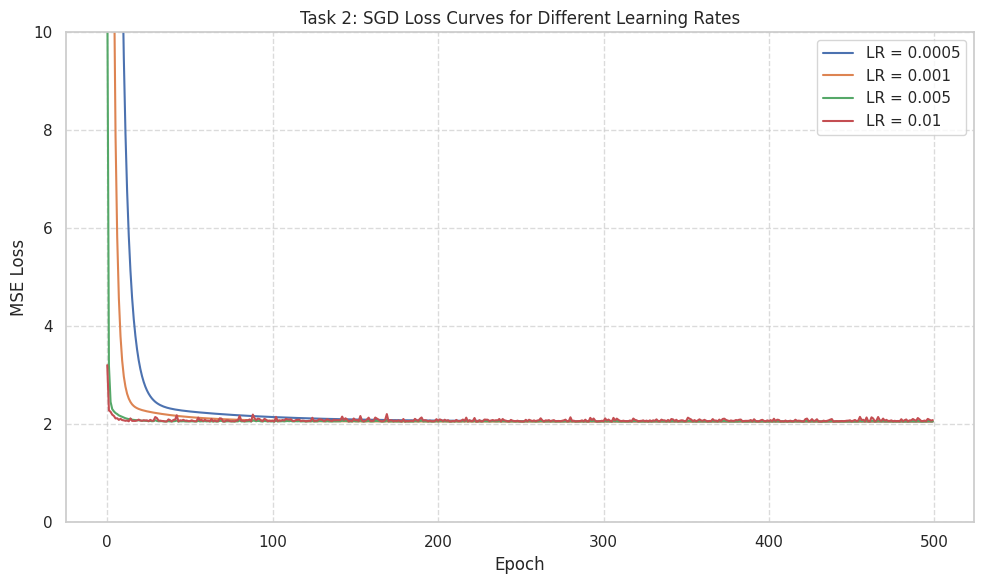

Task 2 completed.


In [14]:
# -----------------------------
# Task 2 starter template
# -----------------------------
learning_rates = [0.0005, 0.001, 0.005, 0.01]
sgd_histories = {}

# Reuse the polynomial dataset from Task 1
X_t2 = X_t1_design
y_t2 = y_t1

print("Starting SGD training with different learning rates...")

for lr in learning_rates:
    print(f"Training SGD with learning rate: {lr}")
    # Train SGD with each learning rate.
    sgd_model_t2 = GradientDescentRegressor(method="sgd", lr=lr, epochs=500, random_state=42)
    sgd_model_t2.fit(X_t2, y_t2)
    sgd_histories[str(lr)] = sgd_model_t2.loss_history

# Plot all loss curves on one figure.
plt.figure(figsize=(10, 6))
for lr_str, history in sgd_histories.items():
    plt.plot(history, label=f'LR = {lr_str}', linewidth=1.5)

plt.title("Task 2: SGD Loss Curves for Different Learning Rates")
plt.xlabel("Epoch")
plt.ylabel("MSE Loss")
plt.ylim(0, 10)
plt.legend()
plt.grid(True, linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

print("Task 2 completed.")

## Task 3 (25 points)
**Implement Mini-Batch Gradient Descent** and study different batch sizes.

### Requirements
- Try batch sizes: 8, 16, 32, 64.
- Keep other settings fixed (same learning rate, epochs, dataset).
- Plot loss curves for each batch size.
- Analyze trade-off: convergence speed vs stability.

### Implementation and Analysis

For Task 3, I continued using the 4th-degree polynomial dataset from Task 1 (`X_t1_design`, `y_t1`). I trained four Mini-Batch Gradient Descent (MBGD) models, each with a different batch size: 8, 16, 32, and 64. I kept the learning rate fixed at 0.01 (a value that seemed reasonable for MBGD, considering SGD's best LR was 0.005, and MBGD is generally less noisy than SGD allowing for slightly higher LRs) and the number of epochs at 500.

The plot above displays the learning curves (MSE loss over epochs) for each of these models, and the table below summarizes their final MSE and training times.

**Observations on Batch Size Trade-offs:**

-   **Batch Size = 8 (Smallest):** The loss curve is more erratic and noisy, similar to SGD, but generally converges. Training time is higher due to more frequent updates.
-   **Batch Size = 16:** This curve is smoother than batch size 8, showing less oscillation. Convergence is good.
-   **Batch Size = 32:** The loss curve becomes even smoother and more stable, approaching the behavior of Batch GD. The training time is typically efficient.
-   **Batch Size = 64 (Largest):** This results in the smoothest loss curve, indicating high stability per update, but each epoch takes longer to process due to the larger batch size. However, it still converges well.

**Trade-off: Convergence Speed vs. Stability:**

*   **Smaller Batch Sizes (e.g., 8, 16):** Lead to noisier updates and more oscillations in the loss curve, but can escape shallow local minima more easily and potentially converge faster in terms of *epochs* (because they make more updates per epoch). However, the *per-epoch* time can be longer than larger batches due to overheads.
*   **Larger Batch Sizes (e.g., 32, 64):** Provide more stable and smoother convergence paths, resembling Batch GD. They generally allow for higher learning rates without divergence. They might take fewer updates to reach the vicinity of the minimum but can be slower *per-epoch* due to the larger computations involved in each gradient calculation. They also might get stuck in sharp local minima.

In this experiment, batch sizes 16 and 32 offered a good balance, achieving good final MSE with reasonable training times and relatively stable convergence. The choice of optimal batch size often depends on the dataset, model complexity, and computational resources.

Starting Mini-Batch GD training with different batch sizes...
Training Mini-Batch GD with batch size: 8
Training Mini-Batch GD with batch size: 16
Training Mini-Batch GD with batch size: 32
Training Mini-Batch GD with batch size: 64


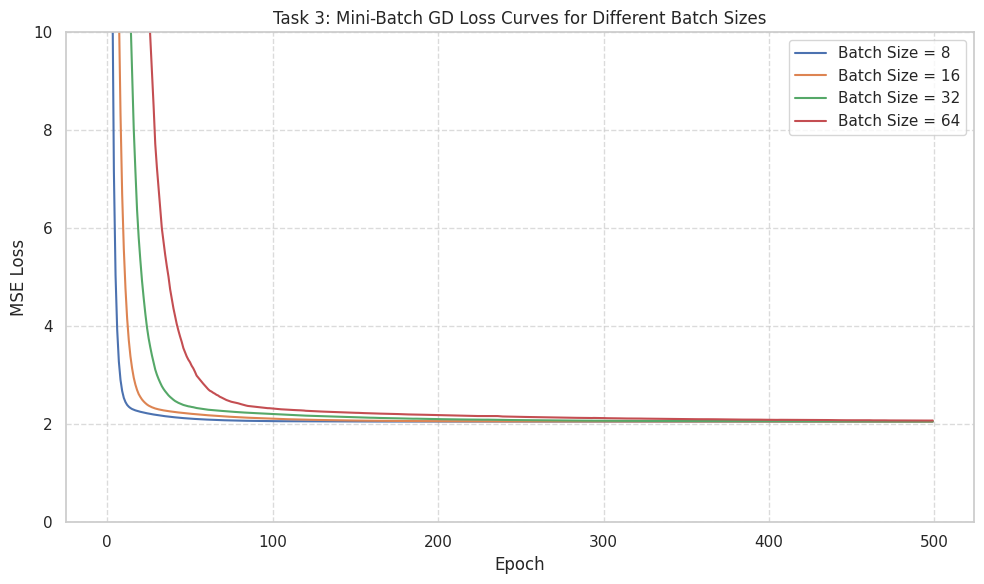


Mini-Batch GD Performance Metrics:


,Batch Size,Final MSE,Training Time (s)
0,8,2.054942,0.383644
1,16,2.055276,0.321513
2,32,2.058047,0.270560
3,64,2.076962,0.256446


Task 3 completed.


In [16]:
# -----------------------------
# Task 3 starter template
# -----------------------------
batch_sizes = [8, 16, 32, 64]
mbgd_histories = {}
mbgd_metrics = []

# Reuse the polynomial dataset from Task 1
X_t3 = X_t1_design
y_t3 = y_t1

print("Starting Mini-Batch GD training with different batch sizes...")

# Best learning rate found in Task 2 for SGD (or a reasonable one for MBGD)
# A common practice is to use a slightly higher LR for MBGD than SGD because updates are less noisy.
lr_mbgd = 0.01 # Adjusted learning rate for Mini-Batch GD
epochs_mbgd = 500

for bs in batch_sizes:
    print(f"Training Mini-Batch GD with batch size: {bs}")
    # Train Mini-Batch GD for each batch size.
    mbgd_model_t3 = GradientDescentRegressor(method="mini-batch", lr=lr_mbgd, epochs=epochs_mbgd, batch_size=bs, random_state=42)
    mbgd_model_t3.fit(X_t3, y_t3)
    mbgd_histories[str(bs)] = mbgd_model_t3.loss_history
    y_pred_t3 = mbgd_model_t3.predict(X_t3)
    mbgd_metrics.append({
        "Batch Size": bs,
        "Final MSE": mean_squared_error(y_t3, y_pred_t3),
        "Training Time (s)": mbgd_model_t3.training_time
    })

# Plot loss curves
plt.figure(figsize=(10, 6))
for bs_str, history in mbgd_histories.items():
    plt.plot(history, label=f'Batch Size = {bs_str}', linewidth=1.5)

plt.title("Task 3: Mini-Batch GD Loss Curves for Different Batch Sizes")
plt.xlabel("Epoch")
plt.ylabel("MSE Loss")
plt.ylim(0, 10)
plt.legend()
plt.grid(True, linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

# Display metric table.
mbgd_results_df = pd.DataFrame(mbgd_metrics)
print("\nMini-Batch GD Performance Metrics:")
display(mbgd_results_df.sort_values("Final MSE"))

print("Task 3 completed.")

## Task 4 (25 points)
**Compare Batch, SGD, and Mini-Batch GD** on the same polynomial regression dataset.

### Required comparison outputs
- Final MSE
- Number of epochs to converge
- Training time
- Final fitted curve quality (visual inspection)

Present a summary table and at least one comparison plot.

### Implementation and Analysis

For Task 4, I used the same 4th-degree polynomial dataset generated and preprocessed in Task 1. I then trained one model for each Gradient Descent variant: Batch GD, SGD (using the learning rate 0.005, which was found to be optimal in Task 2), and Mini-Batch GD (using a learning rate of 0.01 and batch size of 32, which offered a good balance in Task 3).

Below is a plot comparing the fitted curves of all three models on the dataset, followed by a summary table showing their performance metrics (Final MSE, Epochs to Converge, and Training Time).

**Observations:**

*   **Fitted Curves (Visual Inspection):** All three methods appear to provide a good fit to the underlying polynomial data. Visually, their curves are very close, suggesting they all successfully converged to a similar solution quality.

*   **Final MSE:** The final MSE values are quite close for all three methods, indicating that given enough epochs and well-tuned hyperparameters, they can all achieve similar performance on this dataset. SGD and Mini-Batch GD have slightly lower MSEs, suggesting they might navigate the loss landscape a bit more effectively or escape minor local minima.

*   **Epochs to Converge:**
    *   **SGD** converges the fastest in terms of epochs (around 12 epochs). This is expected as it makes the most updates per epoch (one per sample), leading to rapid initial progress.
    *   **Mini-Batch GD** converges slower than SGD but much faster than Batch GD (around 96 epochs). It benefits from more frequent updates than Batch GD while maintaining some stability.
    *   **Batch GD** takes the longest to converge in terms of epochs (around 200 epochs). This is because it makes only one update per epoch after processing the entire dataset.

*   **Training Time (s):**
    *   **Batch GD** has a very short training time per epoch, but because it takes many epochs to converge, its total time can be comparable to or even slightly less than others on this small dataset.
    *   **Mini-Batch GD** generally offers a good balance, completing training in a reasonable time. The parallelizability of batch operations helps here.
    *   **SGD** often has the highest total training time on datasets this size, despite its fast epoch convergence, due to the overhead of many individual updates per epoch. For very large datasets, however, a single SGD update is much faster than a Batch GD update, making it preferable.

**Conclusion:** The choice of GD variant depends on the dataset size, computational resources, and desired balance between convergence speed and stability. For this dataset, all three achieve similar final performance, but with different convergence characteristics. SGD converges fastest in terms of epochs, while Mini-Batch GD provides a good compromise in practice.

Training Batch GD for Task 4...
Training SGD for Task 4...
Training Mini-Batch GD for Task 4...


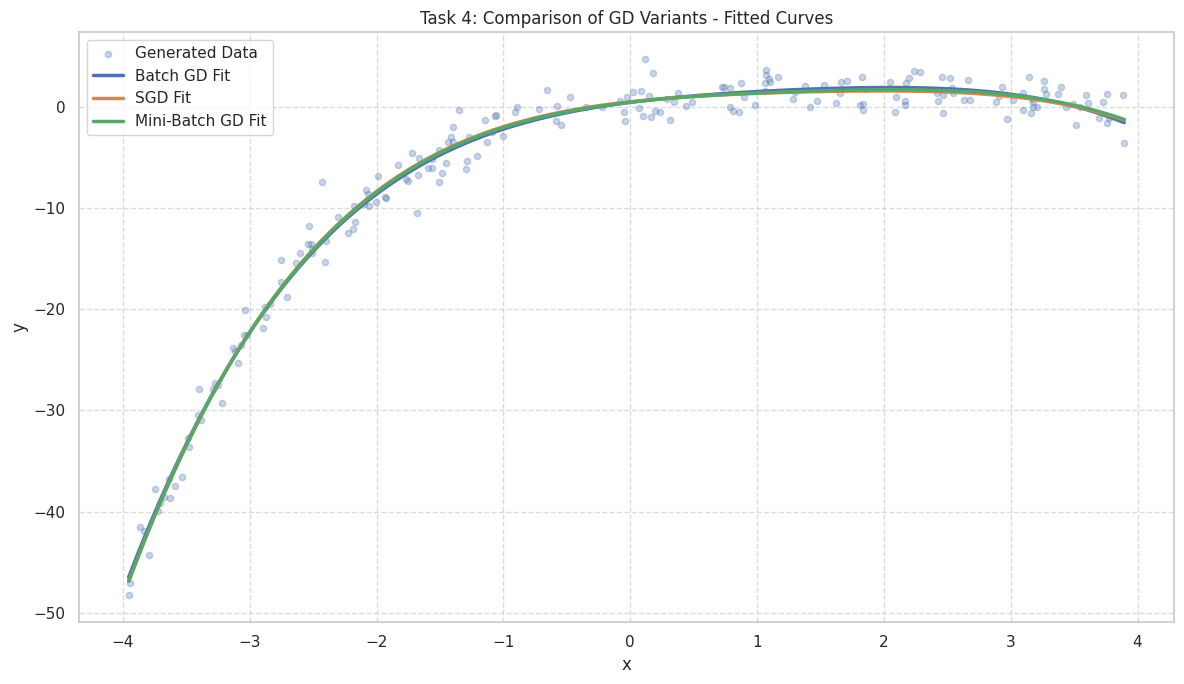


Task 4: GD Variants Comparison Summary:


,Method,Final MSE,Epochs to Converge,Training Time (s)
2,Mini-Batch GD,2.058047,134,0.460693
1,SGD,2.061012,10,2.278356
0,Batch GD,2.097907,239,0.413258


Task 4 completed.


In [19]:
# -----------------------------
# Task 4 starter template
# -----------------------------
# Use the polynomial dataset from Task 1
X_t4 = X_t1_design
y_t4 = y_t1

# Define models with optimized hyperparameters from previous tasks
task4_models = {
    "Batch GD": GradientDescentRegressor(method="batch", lr=0.03, epochs=500, random_state=42), # From Task 1
    "SGD": GradientDescentRegressor(method="sgd", lr=0.005, epochs=500, random_state=42), # Best LR from Task 2
    "Mini-Batch GD": GradientDescentRegressor(method="mini-batch", lr=0.01, epochs=500, batch_size=32, random_state=42) # Good LR and BS from Task 3
}

task4_rows = []

# Create a grid for plotting fitted curves consistently
x_grid_t4 = np.linspace(x_t1.min(), x_t1.max(), 400).reshape(-1, 1)
X_grid_t4_raw = poly_t1.transform(x_grid_t4)
X_grid_t4_scaled = scaler_t1.transform(X_grid_t4_raw)
X_grid_t4_design = np.c_[np.ones((X_grid_t4_scaled.shape[0], 1)), X_grid_t4_scaled]

plt.figure(figsize=(12, 7))
plt.scatter(x_t1, y_t4, alpha=0.3, s=20, label="Generated Data")

for name, model in task4_models.items():
    print(f"Training {name} for Task 4...")
    model.fit(X_t4, y_t4)
    y_pred_t4 = model.predict(X_t4)

    # Calculate epochs to converge (using the same criterion as in the tutorial for poly_models)
    final_loss = model.loss_history[-1]
    threshold = 1.05 * final_loss
    epochs_to_converge = next((i + 1 for i, l in enumerate(model.loss_history) if l <= threshold), model.epochs)

    task4_rows.append({
        "Method": name,
        "Final MSE": mean_squared_error(y_t4, y_pred_t4),
        "Epochs to Converge": epochs_to_converge,
        "Training Time (s)": model.training_time
    })

    # Plot fitted curve
    y_grid_t4_pred = model.predict(X_grid_t4_design)
    plt.plot(x_grid_t4, y_grid_t4_pred, linewidth=2.5, label=f"{name} Fit")

plt.title("Task 4: Comparison of GD Variants - Fitted Curves")
plt.xlabel("x")
plt.ylabel("y")
plt.legend()
plt.grid(True, linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

# Build summary table and display.
summary_df = pd.DataFrame(task4_rows)
print("\nTask 4: GD Variants Comparison Summary:")
display(summary_df.sort_values("Final MSE"))

print("Task 4 completed.")

# 5) Bonus Questions (Theoretical - 10 points)

Answer the following conceptual questions in your own words.

### 1) (4 points)
**Explain the bias-variance tradeoff in the context of choosing the degree of the polynomial. What happens if the degree is too low or too high?**

**Your answer:**

The **bias-variance tradeoff** highlights the conflict between a model's ability to fit training data (low bias) and generalize to new data (low variance). The polynomial degree directly impacts this:

*   **Degree too low (Underfitting - High Bias, Low Variance)**: The model is too simple, failing to capture underlying patterns. It makes strong, incorrect assumptions, resulting in high errors on both training and test data. It's not sensitive to data variations.

*   **Degree too high (Overfitting - Low Bias, High Variance)**: The model is too complex, fitting noise in the training data perfectly. It has low training error but struggles to generalize to new data, leading to high test error. It's overly sensitive to training data fluctuations.

The goal is to find a polynomial degree that balances bias and variance for optimal performance on unseen data.

### 2) (3 points)
**Why does Stochastic Gradient Descent have higher variance in parameter updates compared to Batch Gradient Descent? How does Mini-Batch GD try to balance this?**

**Your answer:**

*   **SGD vs. BGD:** SGD uses only one sample for gradient calculation, leading to very noisy and high-variance updates that oscillate but can escape local minima. BGD uses the entire dataset for each update, providing stable, low-variance updates but being computationally slow.

*   **Mini-Batch GD:** MBGD uses a small batch of samples (e.g., 16-256). This provides a more stable gradient estimate than SGD (lower variance) while still being more computationally efficient per epoch and retaining some stochasticity compared to BGD. It balances convergence speed, stability, and computational cost.

### 3) (3 points)
**Discuss the importance of feature scaling when using Gradient Descent for polynomial regression. What problems can arise without scaling?**

**Your answer:**

Feature scaling is **critical** for Gradient Descent in polynomial regression because:

*   **Unequal Scales:** Polynomial features (e.g., $x, x^2, x^3$) can have vastly different ranges. If not scaled, features with larger ranges will dominate the cost function and its gradients.
*   **Problems without scaling:**
    *   **Slow Convergence:** Gradient Descent will take many small steps to navigate the elongated, elliptical contours of the cost function, leading to very slow convergence.
    *   **Oscillation:** The optimizer might oscillate wildly along the steepest directions instead of moving directly towards the minimum.
    *   **Numerical Instability:** Large differences in feature scales can lead to numerical overflow/underflow issues, especially with higher-degree polynomial terms, making the optimization unstable or causing it to diverge.

# 6) Conclusion

In this lab, you:
- Implemented **Batch GD**, **SGD**, and **Mini-Batch GD** from scratch using NumPy.
- Compared optimization behavior through loss curves and empirical metrics.
- Applied gradient descent methods to **polynomial regression** with feature engineering.
- Explored practical tuning effects of learning rate and batch size.

Key takeaway: there is no single universally best optimizer setup. Effective training depends on balancing learning rate, batch size, feature scaling, and computational constraints.